In [41]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from typing import Tuple

In [152]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 15,
    "mathtext.fontset": "cm",
})

In [89]:
data = np.load('../out/gauss_bonnet.bak/case1.output.npz')

In [4]:
data.files

['linear_spectrums',
 'lat_spectrums',
 'linear_sigw_omega',
 'lat_sigw_omega',
 'linear_k',
 'lat_k',
 'params']

In [149]:
def plot_linear_lattice_comparison(
    linear_k: np.ndarray,
    linear_spectrums: np.ndarray,
    lat_k: np.ndarray,
    lat_spectrums: np.ndarray,\
    xlim: (float, float),
    ylim: (float, float),
    spectrum_ylabel: str,
    comp_ylabel: str,
):
    fig, (ax_spec, ax_comp) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [4, 1]})
    ax_spec.set_xscale('log')
    ax_spec.set_yscale('log')
    ax_spec.set_xlim(*xlim)
    ax_spec.set_ylim(*ylim)
    ax_spec.set_ylabel(spectrum_ylabel)
    ax_comp.set_xscale('log')
    ax_comp.set_yscale('log')
    ax_comp.set_ylim(1e-2, 1)
    ax_comp.set_ylabel(comp_ylabel)
    ax_comp.set_xlabel(r'$k / \mathrm{Hz}$')
    for (linear_spec, lat_spec) in zip(linear_spectrums, lat_spectrums):
        line1, = ax_spec.plot(linear_k, linear_spec, ls = '--')
        ax_spec.plot(lat_k, lat_spec, color = line1.get_color())
        linear_spec_at_lat_k = interp1d(linear_k, linear_spec)(lat_k)
        ax_comp.plot(lat_k, np.abs(1.0 - linear_spec_at_lat_k / lat_spec), color = line1.get_color())
    return fig

In [145]:
def pick_elements(arr: np.ndarray, new_count: int):
    if new_count == -1:
        return arr
    count = len(arr)
    ret = []
    for i in range(new_count):
        ret.append(arr[int(i / (new_count - 1) * (count - 1))])
    return np.array(ret)

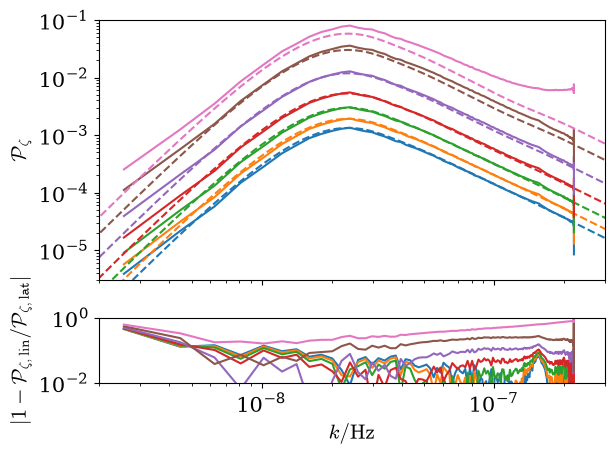

In [153]:
fig = plot_linear_lattice_comparison(
    data['linear_k'],
    pick_elements(data['linear_spectrums'], 7),
    data['lat_k'],
    pick_elements(data['lat_spectrums'], 7),
    xlim = (2e-9, 3e-7),
    ylim = (3e-6, 1e-1),
    spectrum_ylabel = r'$\mathcal{P}_\zeta$',
    comp_ylabel = r'$|1 - \mathcal{P}_{\zeta,\rm lin} / \mathcal{P}_{\zeta, \rm lat}|$',
)
fig.tight_layout()
fig.savefig('plot-gb-primordial-specs.pdf', bbox_inches = 'tight')